In [1]:
import jax
import jax.numpy as jnp

from crn_jax import models
from crn_jax.plotting import plot_species_distributions, plot_species_trajectories

E0514 16:58:58.290052   69349 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 23.52GiB (25251643392 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0514 16:58:58.290317   69349 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 21.17GiB (22726477824 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0514 16:58:58.290568   69349 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 19.05GiB (20453828608 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0514 16:58:58.290819   69349 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 17.14GiB (18408445952 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0514 16:58:58.291061   69349 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 15.43GiB (16567601152 by

## Setup

In [20]:
key = jax.random.PRNGKey(0)
N_REPLICATES = 1000

In [7]:
def run_and_plot_distribution(model, x0, n_steps=200, params=None, title=None):
    """Simulate one trajectory per row of ``x0`` and plot each species' empirical
    marginal distribution over time as a heatmap.

    ``x0`` is a ``(n_replicates, len(model.SPECIES))`` array of per-replicate initial
    counts. ``params`` defaults to ``model.Params.default()`` if not supplied — pass
    a different ``Params`` instance (e.g. ``Params.bistable()``) to override the regime.
    """
    if params is None:
        params = model.Params.default()
    print("Params:", params.__dict__)
    n_replicates = x0.shape[0]
    dataset = models.sample_trajectories(model, params=params, key=key, x0=x0, dt=0.1, n_steps=n_steps)

    if title is None:
        title = f"{model.__name__.rsplit('.', 1)[-1]} (N={n_replicates})"

    return plot_species_distributions(dataset, title=title)


def run_and_plot_trajectories(model, x0, n_steps=200, params=None, title=None, alpha=0.05):
    """Simulate one trajectory per row of ``x0`` and plot the per-species spaghetti.

    Same call interface as ``run_and_plot_distribution`` but renders each replicate
    as an overlaid step-line (grey, semi-transparent — no color coding, density
    emerges from overlap). Useful for bistable / multimodal cases where the
    marginal heatmap loses the joint structure across species.
    """
    if params is None:
        params = model.Params.default()
    print("Params:", params.__dict__)
    n_replicates = x0.shape[0]
    dataset = models.sample_trajectories(model, params=params, key=key, x0=x0, dt=0.1, n_steps=n_steps)

    if title is None:
        title = f"{model.__name__.rsplit('.', 1)[-1]} (N={n_replicates})"

    colors = ["grey"] * len(model.SPECIES)
    return plot_species_trajectories(dataset, title=title, colors=colors, alpha=alpha)

## Many-trajectory ensembles (N=1000)

In [ ]:
# Birth-death. A single species is produced at a constant rate and decays first-order;
# the stationary distribution is Poisson with mean α/δ = 50. Seeding x0 ~ Uniform{0..150}
# (wider than the stationary support) lets us watch every replicate relax back toward
# Poisson(50) over a few decay times (~87 min each).
# Species: X (the species count).
x0 = jax.random.randint(jax.random.PRNGKey(1), (N_REPLICATES, 1), minval=0, maxval=151)
run_and_plot_trajectories(models.birth_death, x0=x0, n_steps=5000)

Params: {'k_R': 0.6, 'gamma_R': 0.3466, 'k_P': 6.931, 'gamma_P': 0.01155}


(<Figure size 700x360 with 4 Axes>,
 array([<Axes: ylabel='R'>, <Axes: xlabel='time', ylabel='P'>],
       dtype=object))

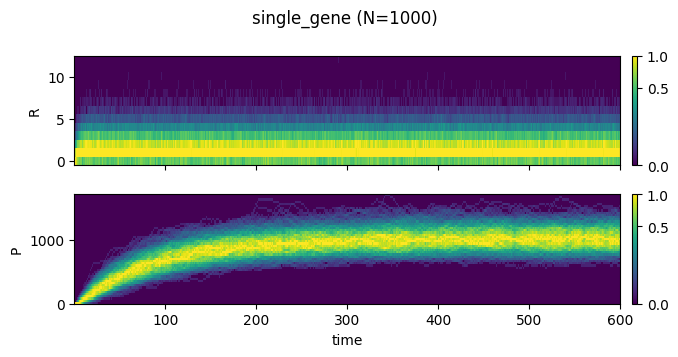

In [ ]:
# Single-gene expression. Transcription produces mRNA constitutively, which is then
# translated into protein; both species decay first-order. The simplest model with a
# hidden delay between input and output.
# Species: R (mRNA), P (protein).

# Start from nothing and watch mRNA slowly increase P until steady-state
x0 = jnp.zeros((N_REPLICATES, 2))
run_and_plot_distribution(models.single_gene, x0=x0, n_steps=6000);

In [ ]:
# Negative autoregulation. A single species represses its own production through a Hill
# term — a classic noise-reducing motif that speeds up response and tightens the
# stationary distribution compared to unregulated expression.
# Species: X (the species count).
# Seed x0 ~ Uniform{0..100} (much wider than the SS spread) to see self-repression
# squeeze the trajectories down to their tight stationary distribution around ⟨X⟩ ≈ 18.
# n_steps=5000 → ~500 min, ~6× the 87-min decay time, enough to relax.
x0 = jax.random.randint(jax.random.PRNGKey(4), (N_REPLICATES, 1), minval=0, maxval=101)
run_and_plot_trajectories(models.negative_autoregulation, x0=x0, n_steps=5000)

In [ ]:
# Positive autoregulation. A single species activates its own production through a Hill
# term. With sub-cooperative Hill (n ≤ 1) the equilibrium is monostable and graded; with
# sharper cooperativity and lower leakage the dynamics become switch-like — see the
# next cell for the bistable regime of this same circuit.
# Species: X (the species count).
# Seed x0 ~ Uniform{0..100} so we see the slow rise / relaxation toward ⟨X⟩ ≈ 46.
x0 = jax.random.randint(jax.random.PRNGKey(5), (N_REPLICATES, 1), minval=0, maxval=101)
run_and_plot_trajectories(models.positive_autoregulation, x0=x0, n_steps=10000)

Params: {'beta_0': 0.0, 'beta_1': 0.5776, 'K': 20.0, 'n': 4.0, 'delta': 0.01155}


(<Figure size 700x180 with 2 Axes>,
 array([<Axes: xlabel='time', ylabel='X'>], dtype=object))

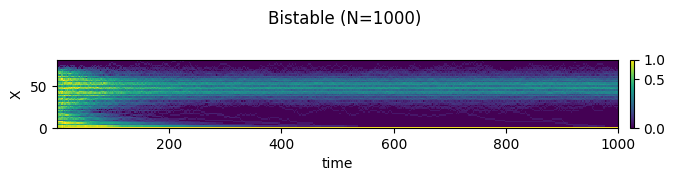

In [ ]:
# Bistable self-activation — same reactions as positive_autoregulation, run in the
# bistable regime via Params.bistable() (BE150 dimensionless ratios β/(γK) = 2.5,
# n = 4, scaled to copy numbers high enough for stochastic persistence).
# Three deterministic fixed points: X=0 (stable, absorbing), X_saddle ≈ 17, X_high ≈ 49.
# Species: X (the species count).
# Spread x0 ~ Uniform{0..70} so some replicates start below the saddle (commit to
# X=0 and stay there) and others above (commit to high). Trajectory spaghetti shows
# the bimodal commitment directly.
x0 = jax.random.randint(jax.random.PRNGKey(6), (N_REPLICATES, 1), minval=0, maxval=70)
run_and_plot_distribution(
    models.positive_autoregulation,
    x0=x0,
    n_steps=10000,
    params=models.positive_autoregulation.Params.bistable(),
    title=f"Bistable (N={N_REPLICATES})",
);

In [ ]:
# Linear activation cascade. A is produced at a constant rate and decays first-order.
# A then activates B through a Hill term. The simplest open signalling cascade.
# Species: A (upstream driver), B (downstream target).
# Seed both species ~ Uniform{0..100} (wider than the SS spread of ⟨A⟩=50, ⟨B⟩≈26).
x0 = jax.random.randint(jax.random.PRNGKey(7), (N_REPLICATES, 2), minval=0, maxval=101)
run_and_plot_trajectories(models.linear_cascade, x0=x0, n_steps=5000)

In [ ]:
# Toggle switch (Lugagne et al. 2017 E. coli LacI/TetR fit, adiabatically reduced).
# Two species mutually repress each other; the system is bistable, with LacI-wins
# (A high, B low) and TetR-wins (A low, B high) as stable basins.
# Species: A = LacI, B = TetR. Units: a.u. (fluorescence).
# Three deterministic fixed points: LacI-wins (A≈660, B≈63); TetR-wins (A≈18, B≈864);
# saddle at (A≈73, B≈228).
#
# Use N=100 (50 seeded inside each basin) so the trajectory spaghetti stays readable —
# the marginal heatmap would obscure the joint structure (A-low cells are the same
# cells as B-high cells), while trajectory plots make basin commitment obvious.
k_LacI, k_TetR = jax.random.split(jax.random.PRNGKey(8))
N_HALF = 50
x0_LacI = jax.random.randint(k_LacI, (N_HALF, 2), minval=jnp.array([600, 0]), maxval=jnp.array([1000, 100]))
x0_TetR = jax.random.randint(k_TetR, (N_HALF, 2), minval=jnp.array([0, 700]), maxval=jnp.array([50, 1200]))
x0 = jnp.concatenate([x0_LacI, x0_TetR], axis=0)
run_and_plot_trajectories(models.toggle_switch, x0=x0, n_steps=10000, alpha=0.15)

In [ ]:
# Incoherent feed-forward loop (Mangan & Alon 2003). A activates both B and C, while B
# represses C. The opposing direct (A→C) and indirect (A→B⊣C) paths produce a pulse /
# adaptive response on C: C transiently rises after A turns on, then falls as the slower
# repression through B kicks in.
# Species: A (input), B (intermediate repressor), C (output).
# Seed A at its SS (50) and B = C = 0 — mimics "input signal just turned on".
# C should peak around ~5 then fall toward ~1 as B catches up. n_steps=5000 → 500 min.
x0_A = jnp.full((N_REPLICATES, 1), 50, dtype=jnp.int32)
x0_BC = jnp.zeros((N_REPLICATES, 2), dtype=jnp.int32)
x0 = jnp.concatenate([x0_A, x0_BC], axis=-1)
run_and_plot_trajectories(models.incoherent_ffl, x0=x0, n_steps=5000)

In [ ]:
# Repressilator (Elowitz & Leibler 2000). A three-node repressive ring in which A
# represses B, B represses C, and C represses A. With sufficient Hill cooperativity
# the system enters a stable limit cycle — Elowitz's synthetic E. coli oscillator.
# Species: A, B, C (the three mutually-repressing genes). ⟨X⟩_max ≈ 8650 monomers.
# Sample x0 ~ Uniform{0..5000} for each species — wide enough to span the dynamic
# range. n_steps=15000 dt=0.2 → 3000 min ≈ 18 full cycles. With N=1000 replicates at
# random phase, individual trajectories cycle but the spaghetti smears out the
# oscillation — the per-trajectory cycle isn't directly visible here.
x0 = jax.random.randint(jax.random.PRNGKey(13), (N_REPLICATES, 3), minval=0, maxval=5001)
run_and_plot_trajectories(models.repressilator, x0=x0, n_steps=15000)